In [1]:
import os
from pathlib import Path
from typing import Dict, List, Tuple
# import argparse
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# ============================================================================
# COLOR CONFIGURATION CENTER - Customize all colors here
# ============================================================================

# Option 1: Current colors (default)
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:blue',
    'gaussian_ppo': 'tab:green', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

# Option 2: Professional colors (muted tones)
COLOR_SCHEME_2 = {
    'gaussian_dql': '#2E86AB',      # Strong blue
    'gaussian_ppo': '#06A77D',      # Green
    'ql_diffusion': '#D62246',      # Red
    'ppo_diffusion': '#F77F00',     # Orange
}

# Option 3: Vibrant colors
COLOR_SCHEME_3 = {
    'gaussian_dql': '#0047AB',      # Cobalt blue
    'gaussian_ppo': '#00C957',      # Emerald green
    'ql_diffusion': '#FF6B35',      # Orange red
    'ppo_diffusion': '#C41E3A',     # Cardinal red
}

# Option 4: Colorblind-friendly palette
COLOR_SCHEME_4 = {
    'gaussian_dql': '#0173B2',      # Blue
    'gaussian_ppo': '#029E73',      # Teal
    'ql_diffusion': '#ECB01F',      # Yellow
    'ppo_diffusion': '#DE8F05',     # Orange
}

# Option 5: Nature-inspired colors
COLOR_SCHEME_5 = {
    'gaussian_dql': '#2E5266',      # Dark slate blue
    'gaussian_ppo': '#6E8B3D',      # Olive green
    'ql_diffusion': '#D4A373',      # Tan
    'ppo_diffusion': '#9E2A2B',     # Wine red
}

# ============================================================================
# SELECT YOUR COLOR SCHEME HERE (change the number 1-5)
# ============================================================================
SELECTED_SCHEME = 1  # Change this to 1, 2, 3, 4, or 5

# Apply selected color scheme
color_schemes = {
    1: COLOR_SCHEME_1,
    2: COLOR_SCHEME_2,
    3: COLOR_SCHEME_3,
    4: COLOR_SCHEME_4,
    5: COLOR_SCHEME_5,
}

# Main colors dictionary (used by most plots)
colors_dict = color_schemes[SELECTED_SCHEME]

# Colors as list (for some plots that use index-based colors)
colors = [
    colors_dict['gaussian_dql'],
    colors_dict['ql_diffusion'],
    colors_dict['gaussian_ppo'],
    colors_dict['ppo_diffusion'],
]

print("✓ Color scheme loaded successfully!")
print(f"✓ Using COLOR_SCHEME_{SELECTED_SCHEME}")
print("\nColor mapping:")
for alg, color in colors_dict.items():
    print(f"  {alg:20s} → {color}")


✓ Color scheme loaded successfully!
✓ Using COLOR_SCHEME_1

Color mapping:
  gaussian_dql         → tab:blue
  gaussian_ppo         → tab:green
  ql_diffusion         → tab:orange
  ppo_diffusion        → tab:red


In [3]:
# Algorithm name mapping for display
def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())

colors = {
    'ppo_diffusion': 'tab:red',
    'ql_diffusion': 'tab:orange',
    'gaussian_ppo': 'tab:green',
    'gaussian_dql': 'tab:blue',
}

colors = colors_dict

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")   # quay về style mặc định (nền trắng)

# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

# Set style for better plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")




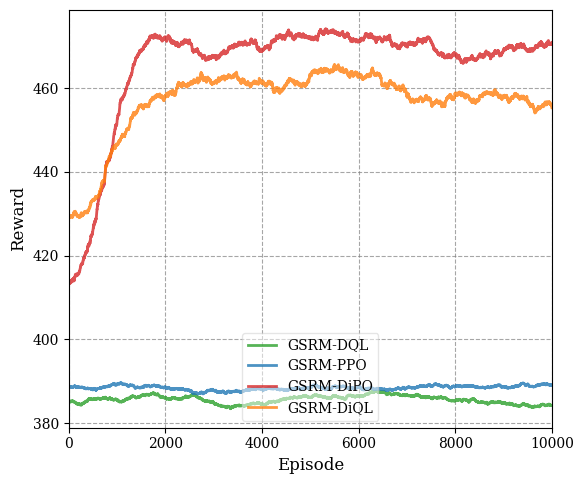

In [6]:

from pathlib import Path
import json
seed = 45
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")
qos_required = [25.0, 30.0, 35.0]
num_users = [8, 10, 12]
M_max = 48
# Collect data from all training runs
def load_training_dataQU(logs_dir, qos_required, num_users):
    training_data = {}

    for folder in sorted(logs_dir.iterdir()):

        for i in range(len(qos_required)):
            for j in range(len(num_users)):
                if folder.name not in training_data:
                    training_data[folder.name] = {}
                if str(qos_required[i]) not in training_data[folder.name]:
                    training_data[folder.name][str(qos_required[i])] = {}
                if str(num_users[j]) not in training_data[folder.name][str(qos_required[i])]:
                    training_data[folder.name][str(qos_required[i])][str(num_users[j])] = {}
                if folder.is_dir():
                    metrics_file = folder / f"training_metrics_qos_{float(qos_required[i])}_users_{num_users[j]}_Mmax_{M_max}.json"
                    # print(f"Loading metrics from: {metrics_file}")
                    if metrics_file.exists():
                        with open(metrics_file, 'r') as f:
                            data = json.load(f)
                        if "episode_rewards" in data:
                            training_data[folder.name][str(qos_required[i])][str(num_users[j])] = data["episode_rewards"]
                            # print(f"✓ Loaded {folder.name}: {len(data['episode_rewards'])} episodes")
                        else:
                            print(f"✗ No episode_rewards in {folder.name}")
                            # pass
    return training_data
training_data = load_training_dataQU(logs_dir, qos_required, num_users)
import matplotlib.pyplot as plt

def smooth_rewards(rewards, window=200):
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(rewards, size=window)

colors = {
     'ql_diffusion': {
        '25.0': {'8': '#B8860B',    # darkgoldenrod (tối)
               '10': '#FFD700',      # gold (vừa)
               '12': '#FFFFE0'},     # lightyellow (sáng)
        '30.0': {'8': '#DAA520',    # goldenrod
               '10': '#F0E68C',      # khaki
               '12': '#FFFACD'},     # lemonchiffon
        '35.0': {'8': '#BDB76B',    # darkkhaki
               '10': '#EEE8AA',      # palegoldenrod
               '12': '#FAFAD2'},     # lightgoldenrodyellow
    },
    'ppo_diffusion': {
        '25.0': {'8': '#8B0000',    # darkred (tối)
               '10': '#DC143C',      # crimson (vừa)
               '12': '#FFB6C1'},     # lightpink (sáng)
        '30.0': {'8': '#B22222',    # firebrick
               '10': '#FF0000',      # red
               '12': '#FFA07A'},     # lightsalmon
        '35.0': {'8': '#CD5C5C',    # indianred
               '10': '#FF6347',      # tomato
               '12': '#F08080'},     # lightcoral
    },
    'gaussian_ppo': {
        '25.0': {'8': '#00008B',    # darkblue (tối)
               '10': '#4169E1',      # royalblue (vừa)
               '12': '#87CEEB'},     # skyblue (sáng)
        '30.0': {'8': '#0000CD',    # mediumblue
               '10': '#1E90FF',      # dodgerblue
               '12': '#87CEFA'},     # lightskyblue
        '35.0': {'8': '#4682B4',    # steelblue
               '10': '#00BFFF',      # deepskyblue
               '12': '#B0E0E6'},     # powderblue
    },
    'gaussian_dql': {
        '25.0': {'8': '#006400',    # darkgreen (tối)
               '10': '#32CD32',      # limegreen (vừa)
               '12': '#90EE90'},     # lightgreen (sáng)
        '30.0': {'8': '#228B22',    # forestgreen
               '10': '#00FF00',      # lime
               '12': '#98FB98'},     # palegreen
        '35.0': {'8': '#2E8B57',    # seagreen
               '10': '#00FA9A',      # mediumspringgreen
               '12': '#AFEEEE'},     # paleturquoise
    },
}

def plotting_rewardQU(training_data, qos = [30.0], users = [8, 10, 12], is_out=False, colors = colors, window = 1000):
    plt.figure(figsize=(6, 5))
    for i in range(len(qos)):
        for j in range(len(users)):
            for alg_name in training_data.keys():
                label = f"{get_algorithm_display_name(alg_name)}"
                rewards =  training_data[alg_name][str(qos[i])][str((users[j]))]
                if alg_name == "ppo_diffusion":
                    rewards = [rewards[k]+10 for k in range(len(rewards))] 
                plt.plot(smooth_rewards(rewards, window), 
                         label=label, color=colors[alg_name][str(qos[i])][str(users[j])], alpha=0.8)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.xlim(0, 10000)
    if is_out:
        plt.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5)) # set legend outside
    else:
        plt.legend(fontsize=10, loc='lower center', framealpha=0.5)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'compare.png', dpi=300)
    

colors = {
     'ql_diffusion': {
        '25.0': {'8': 'tab:orange',    # darkgoldenrod (tối)
               '10': 'tab:orange',      # gold (vừa)
               '12': 'tab:orange'},     # lightyellow (sáng)
        '30.0': {'8': 'tab:orange',    # goldenrod
               '10': 'tab:orange',      # khaki
               '12': 'tab:orange'},     # lemonchiffon
        '35.0': {'8': 'tab:orange',    # darkkhaki
               '10': 'tab:orange',      # palegoldenrod
               '12': 'tab:orange'},     # lightgoldenrodyellow
    },
    'ppo_diffusion': {
        '25.0': {'8': 'tab:red',    # darkred (tối)
               '10': 'tab:red',      # crimson (vừa)
               '12': 'tab:red'},     # lightpink (sáng)
        '30.0': {'8': 'tab:red',    # firebrick
               '10': 'tab:red',      # red
               '12': 'tab:red'},     # lightsalmon
        '35.0': {'8': 'tab:red',    # indianred
               '10': 'tab:red',      # tomato
               '12': 'tab:red'},     # lightcoral
    },
    'gaussian_ppo': {
        '25.0': {'8': 'tab:blue',    # darkblue (tối)
               '10': 'tab:blue',      # royalblue (vừa)
               '12': 'tab:blue'},     # skyblue (sáng)
        '30.0': {'8': 'tab:blue',    # mediumblue
               '10': 'tab:blue',      # dodgerblue
               '12': 'tab:blue'},     # lightskyblue
        '35.0': {'8': 'tab:blue',    # steelblue
               '10': 'tab:blue',      # deepskyblue
               '12': 'tab:blue'},     # powderblue
    },
    'gaussian_dql': {
        '25.0': {'8': 'tab:green',    # darkgreen (tối)
               '10': 'tab:green',      # limegreen (vừa)
               '12': 'tab:green'},     # lightgreen (sáng)
        '30.0': {'8': 'tab:green',    # forestgreen
               '10': 'tab:green',      # lime
               '12': 'tab:green'},     # palegreen
        '35.0': {'8': 'tab:green',    # seagreen
               '10': 'tab:green',      # mediumspringgreen
               '12': 'tab:green'},     # paleturquoise
    },
}


plotting_rewardQU(training_data, [30.0], [10], False, colors, 1500)
# plotting_rewardQU(training_data, [25.0], [10], False, colors, 1500)
# plotting_rewardQU(training_data, [25.0], [12], False, colors, 1500)
# plotting_rewardQU(training_data, [30.0], [8], False, colors, 1500)
# plotting_rewardQU(training_data, [30.0], [10], False, colors, 1500)
# plotting_rewardQU(training_data, [30.0], [12], False, colors, 1500)
# plotting_rewardQU(training_data, [35.0], [8], False, colors, 1500)
# plotting_rewardQU(training_data, [35.0], [10], False, colors, 1500)
# plotting_rewardQU(training_data, [35.0], [12], False, colors, 1500)